# KA3005P forward / backward voltage sweep

Python / pyserial version of `KA3005Ppv.m`. It sweeps the power supply voltage and plots the measured voltage-current characteristic using Matplotlib.

Install dependencies if necessary: `pip install pyserial matplotlib numpy`.

Aufbau und Verwendung
  - Netzgerät anschalten und mit dem Rechner verbinden
  - Elektronische Last im CR Modus mit 20 Ohm oder
    12 V Lampe (minmal 12 W) an das Netzgerät anschließen
  - Com Port anpassen
  - Dieses Skript starten

Copyright, 2021, Mathias Moog, Hochschule Ansbach, Deutschland, CC-BY-NC-SA

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import Skripte

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from Skripte.Ka3005P import Ka3005P

In [15]:
ka = Ka3005P()
ka.connect("COM24")
#ka.connect("/dev/ttyACM0")
ka.get_version()

Ka3005P, connect with port COM24


'KORADKA3005PV2.0\x00'

## Run the sweep

Bitte aufpassen. Der Sweep läuft ohne Nachfrage

In [16]:
MAX_CURRENT_A = 5.0
MAX_VOLTAGE_V = 12.0
VOLTAGES_STEP_V = 0.5
SETTLING_DELAY_S = 0.1

In [17]:

# Erst mal Spannung auf 0
ka.set_voltage( 0)
# Maximal Strom 2 A
ka.set_current( MAX_CURRENT_A)
# an schalten
ka.set_on_off( 1)

print("Voltage sweep up")
Uv, Iv  = ka.voltage_sweep( np.arange(0.0, MAX_VOLTAGE_V + 0.25, VOLTAGES_STEP_V), SETTLING_DELAY_S )

print("Voltage sweep down")
Ur, Ir  = ka.voltage_sweep( np.arange(MAX_VOLTAGE_V, -0.5, -VOLTAGES_STEP_V), SETTLING_DELAY_S )

# aus schalten
print("Switching off")
ka.set_on_off( 0 )


Voltage sweep up
Voltage sweep down
Switching off


In [18]:
ka.disconnect()

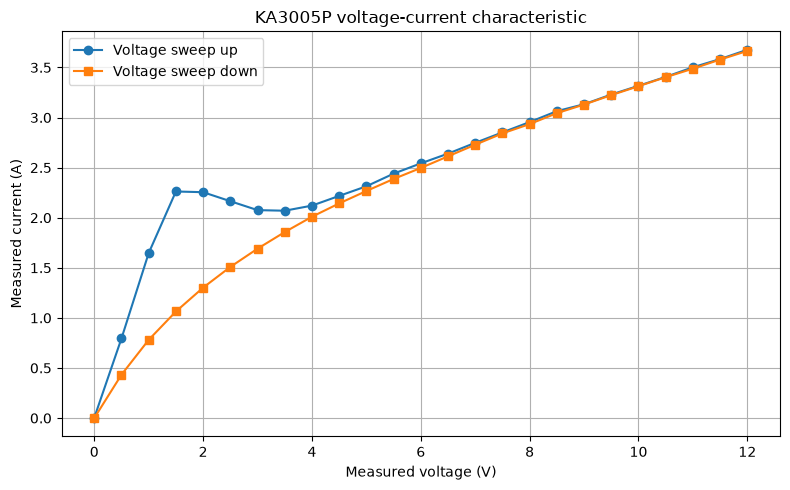

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(Uv, Iv, "o-", label="Voltage sweep up")
plt.plot(Ur, Ir, "s-", label="Voltage sweep down")
plt.xlabel("Measured voltage (V)")
plt.ylabel("Measured current (A)")
plt.title("KA3005P voltage-current characteristic")
plt.grid(True)
plt.tight_layout()
plt.legend()

Optionally save the measured sweep data to a CSV file:

In [22]:
np.savetxt(
    "KA3005Ppv.csv",
    np.column_stack((Uv, Iv, Ur, Ir)),
    delimiter=",",
    header="voltage_forward_V,current_forward_A,voltage_reverse_V,current_reverse_A",
    comments="",
)